In [3]:
from algs.kern_cd import KernCD
from algs.kernels import SigKernel

from sklearn.preprocessing import StandardScaler
from sktime.dists_kernels import SignatureKernel
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from utils.windows import make_windows
from algs.kernels import SigKernel

In [4]:
npz = np.load('../data/humanoid/train.npz')
x = npz['states']
fail = npz['fail']

x = StandardScaler().fit_transform(x.reshape(-1, x.shape[-1])).reshape(x.shape)
y = fail > 0
x.shape

(1000, 1000, 348)

In [88]:
x = x[:100, :, :]
y = y[:100]

win = make_windows(x, fail, window=40, horizon=20)

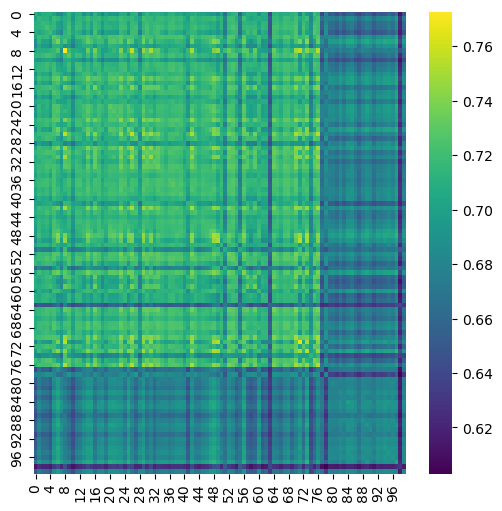

In [89]:
kernel = partial(rbf_kernel, gamma=.001)
k = SignatureKernel(kernel=kernel, normalize=True)
K = k(win[:, :].swapaxes(1, 2))

idx = np.argsort(y)  # reorder by label
K_sorted = K[np.ix_(idx, idx)]

plt.figure(figsize=(6,6))
sns.heatmap(K_sorted, cmap='viridis')
plt.show()

## Try the kernelized CD

In [5]:
npz = np.load('../data/humanoid/test.npz')
x_te = npz['states']
fail_te = npz['fail']

x_te = StandardScaler().fit_transform(x_te.reshape(-1, x.shape[-1])).reshape(x_te.shape)
y_te = fail_te > 0

In [6]:
win_len = 40
hor = 20

win = make_windows(x, fail, window=win_len, horizon=hor)
win_te = make_windows(x_te, fail_te, window=win_len, horizon=hor)

In [7]:
win.shape

(1000, 40, 348)

In [8]:
tr_idx = np.where(fail == 0)[0][:100]
cal_idx = np.where(fail == 0)[0][100:200]

p = KernCD(SigKernel(gamma=0.001), lam=1e-4).fit(win[tr_idx])

In [14]:
q = np.quantile(p.predict(win[cal_idx]), q=0.95)
print(f'q: {q}')

q: 98.6476272207435


In [15]:
win_te = win_te[:200]
fail_te = fail_te[:200]

y_pred = p.predict(win_te)

In [21]:
np.mean(y_pred[fail_te > 0] > q)

np.float64(0.5172413793103449)

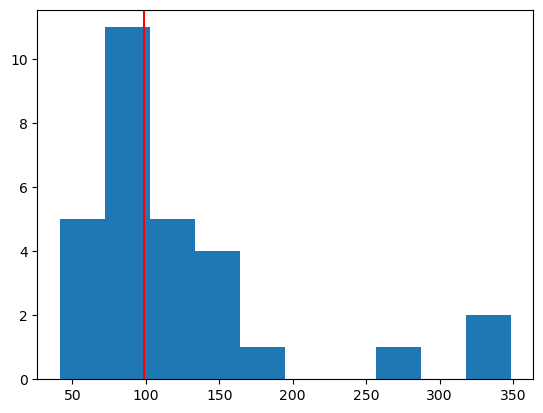

In [22]:
plt.hist(x=y_pred[fail_te > 0])
plt.axvline(q, color='red')